In [3]:
from rdkit import Chem
from rdkit.Chem import Recap, BRICS
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import rdScaffoldNetwork
from rdkit.Chem import AllChem

from rdkit.Chem import rdmolops
import scaffoldgraph as sg


/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#  4,C=c1cc2c(=Cc3ccc(C)s3)oc(O)c2c(=S)[nH]1,[1*]c1ccc(C=c2oc([2*])c3c(=S)[nH]c(=C)cc23)s1,[1*]C.[2*]O,CHEMBL1000314,B,1

mols = list(map(lambda s:Chem.MolFromSmiles(s), 
    '''CCc1c(Oc2cc(C)cc(C)c2)n(CCC2CCCC2)c(=O)[nH]c1=O
    Nc1ccc(-c2ccc(OCc3nnc(SC4CCCC4)n3-c3cccnc3)cc2)cc1
    CCCCNC(=O)c1cnn2c(C)c(Cc3c(C)cc(C)cc3C)c(C)nc12
    O=C(NCc1ccco1)C1CCN(S(=O)(=O)c2ccc(Cl)cc2)CC1
    CN1CCC(=C2c3ccccc3C=Cc3ccccc32)CC1
    '''.split()
))


In [16]:

def tree_frags_from_mol(mol, weight_ratio=0.5):
    scaffold = sg.core.Scaffold(sg.core.fragment.get_murcko_scaffold(mol))
    rdmolops.RemoveStereochemistry(scaffold.mol)
    parents = [scaffold]
    # fragmenter = sg.core.MurckoRingFragmenter(use_scheme_4=True)
    fragmenter = sg.core.MurckoRingSystemFragmenter()
    minimal_core_weight = AllChem.CalcExactMolWt(mol) * weight_ratio 
    rules = sg.prioritization.original_ruleset
    original_rings_count = scaffold.rings.count
    
    def _next_scaffold(child):
        next_parents = [p for p in fragmenter.fragment(child) if (p and AllChem.CalcExactMolWt(p.mol)> minimal_core_weight)]
        if not next_parents:
            return
        next_parent = rules(child, next_parents)
        parents.append(next_parent)
        if next_parent.rings.count > 1:
            _next_scaffold(next_parent)

    _next_scaffold(scaffold)
    # for p in reversed(parents):
    #     try:
    #         sidechains = Chem.ReplaceCore(mol, p.mol)
    #         Chem.SanitizeMol(sidechains)
    #         if original_rings_count == sidechains.GetRingInfo().NumRings() + p.rings.count:
    #             return p.mol
    #     except Exception as e:
    #         print(f"Error processing scaffold {p.smiles}: {e}")
    #         continue
    return [p.mol for p in parents]

In [6]:

from collections import defaultdict


def set_hole_ids(mol, core):
    near_holes = []
    hole_usage_counter = defaultdict(int)
    for atom in core.GetAtoms():
        if atom.GetSymbol() == '*':
            iso = atom.GetIsotope()
            for neighbor in atom.GetNeighbors():
                n_id = neighbor.GetIntProp("__origIdx")
                near_holes.append(n_id)
                hole_usage_counter[n_id] += 1
                mol.GetAtomWithIdx(n_id).SetIntProp("__holeIdx", hole_usage_counter[n_id])
    return near_holes


def get_core_and_chains(m1,core_weight):
    error = [None] * 5
    if  isinstance(m1,str):
        m1 = Chem.MolFromSmiles(m1)
    if m1 is None:
        return error
    for a in m1.GetAtoms():
        a.SetIntProp("__origIdx", a.GetIdx())
    # clean_core = MurckoScaffold.GetScaffoldForMol(m1)
    clean_core = tree_frags_from_mol(m1,core_weight)
    if clean_core is None:
        return error
    core = Chem.ReplaceSidechains(m1, clean_core)
    sidechains = Chem.ReplaceCore(m1, clean_core)
    if core is None or sidechains is None:
        return error
    core_smiles = Chem.MolToSmiles(core)
    sidechains_smiles = Chem.MolToSmiles(sidechains)
    if core_smiles == '' or sidechains_smiles == '':
        return error
    
    hole_neighbors = set_hole_ids(m1, core)
    return clean_core, core_smiles, sidechains ,sidechains_smiles, hole_neighbors


In [ ]:
from itertools import zip_longest
from typing import List

def show_trees(mols,w):
    frags = {}
    for i, mol in enumerate(mols):
        frags[i] = tree_frags_from_mol(mol,w)
    print(frags)
    frags_list = sum(map(list,zip_longest(*frags.values())), [])
        
    return Draw.MolsToGridImage(frags_list,
                        molsPerRow=len(frags), subImgSize=(200,200))

def show_tree(mol, w):
    org_weight = AllChem.CalcExactMolWt(mol)
    frags: List[Chem.Mol] = tree_frags_from_mol(mol, w)
    weights = [f"{AllChem.CalcExactMolWt(f)/org_weight:.2f}" for f in frags]
    return Draw.MolsToGridImage(
        frags,
        molsPerRow=len(frags),
        subImgSize=(400, 400),
        legends=weights,
    )

In [17]:
print(tree_frags_from_mol(mols[1]))

[<rdkit.Chem.rdchem.Mol object at 0x7fd918802350>, <rdkit.Chem.rdchem.Mol object at 0x7fd918802f20>, <rdkit.Chem.rdchem.Mol object at 0x7fd918802190>]


In [29]:
show_tree(mols[1],0.7)


ArgumentError: Python argument types in
    MolDraw2D.DrawMolecules(MolDraw2DCairo, list)
did not match C++ signature:
    DrawMolecules(RDKit::MolDraw2D {lvalue} self, boost::python::api::object mols, boost::python::api::object highlightAtoms=None, boost::python::api::object highlightBonds=None, boost::python::api::object highlightAtomColors=None, boost::python::api::object highlightBondColors=None, boost::python::api::object highlightAtomRadii=None, boost::python::api::object confIds=None, boost::python::api::object legends=None)

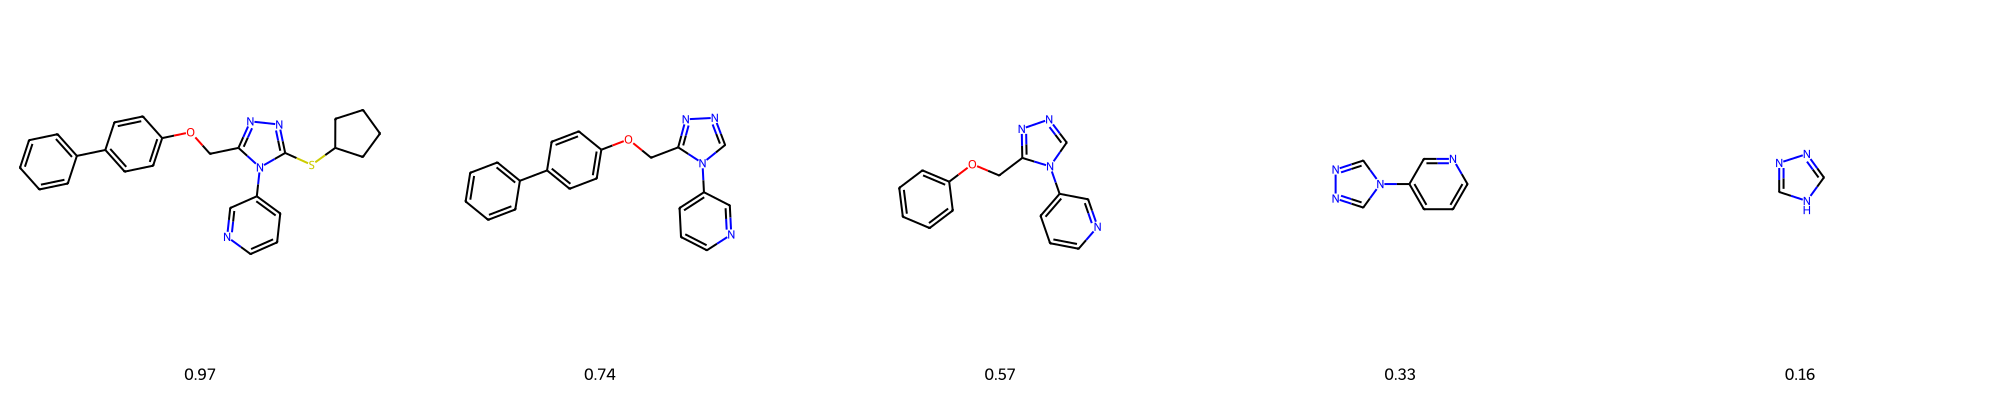

In [27]:
show_tree(mols[1],0.0)


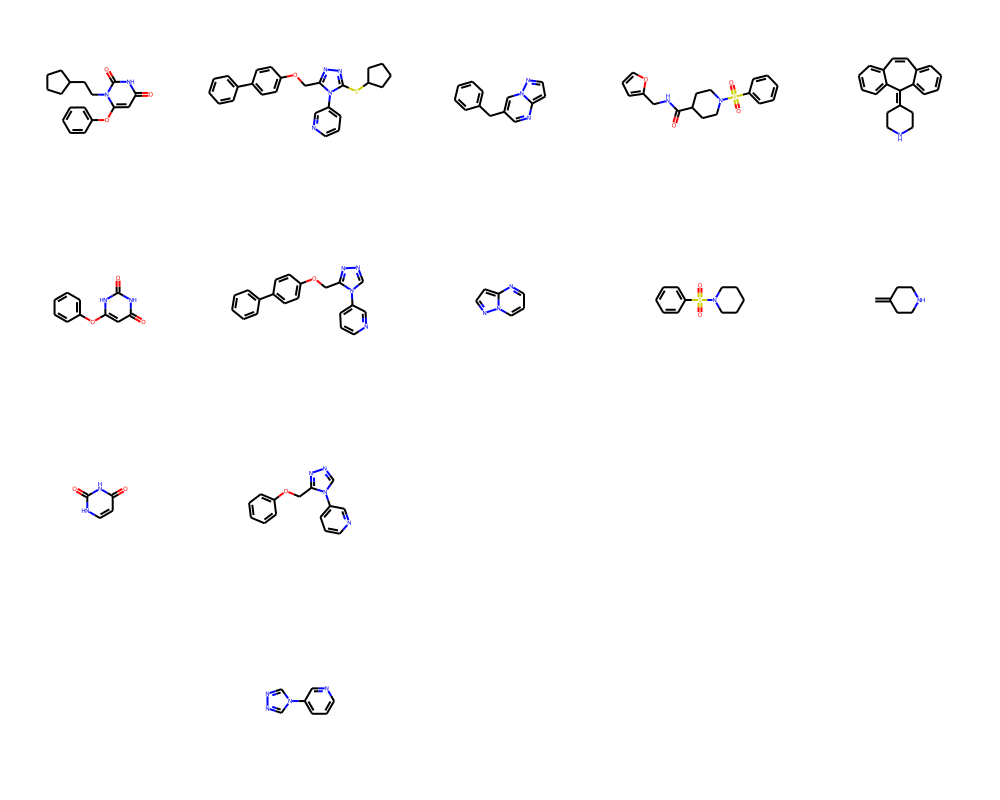

In [ ]:
show_tree(mols,0.3)


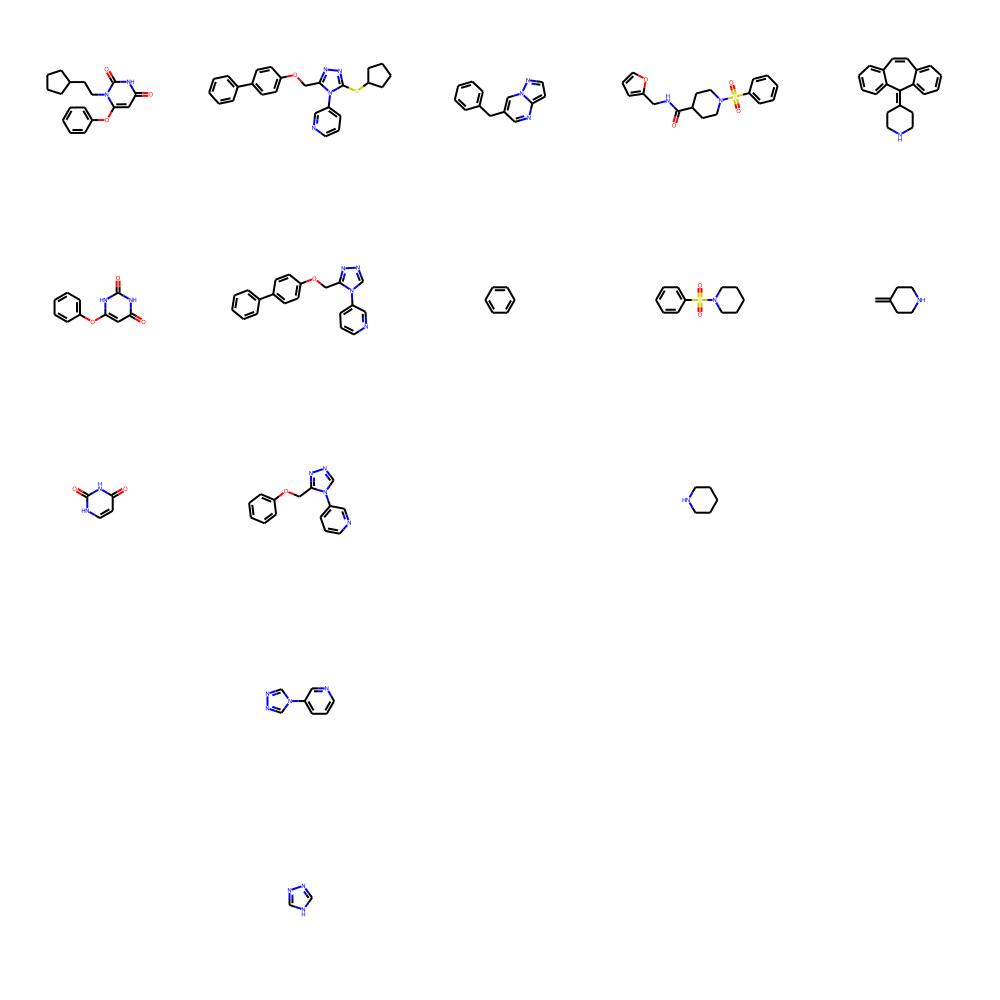

In [ ]:
show_tree(mols,0)


In [ ]:
import pandas as pd
from rdkit import Chem
fails = []
res = []
i=0
def flip(sdf_file):
    
    mol = Chem.SDMolSupplier(sdf_file)[0]
    if mol is None:
        return 1
    sml = Chem.MolToSmiles(mol)
    try:
        tree_frags_from_mol(mol,0)
    except Exception as e:
        print(e)
        fails.append((sml, str(e)))
        return 2
    return sml


df = pd.read_csv('data/fsdock/valid_tasks.csv')
for p in df['ligand_path'].values:
    res.append(flip(p))

[10:38:16] non-ring atom 9 marked aromatic
[10:38:16] non-ring atom 9 marked aromatic
[10:38:16] non-ring atom 9 marked aromatic
[10:38:16] non-ring atom 9 marked aromatic
[10:38:17] ERROR: Cannot convert ' O ' to int on line 5
[10:38:17] ERROR: moving to the beginning of the next molecule
[10:38:26] non-ring atom 0 marked aromatic
[10:38:26] non-ring atom 5 marked aromatic
[10:38:26] non-ring atom 0 marked aromatic
[10:38:26] non-ring atom 5 marked aromatic
[10:38:29] non-ring atom 0 marked aromatic
[10:38:29] non-ring atom 5 marked aromatic
[10:38:29] non-ring atom 0 marked aromatic
[10:38:29] non-ring atom 5 marked aromatic
[10:38:38] non-ring atom 0 marked aromatic
[10:38:38] non-ring atom 9 marked aromatic
[10:38:38] non-ring atom 5 marked aromatic
[10:38:50] non-ring atom 0 marked aromatic
[10:38:50] non-ring atom 5 marked aromatic
[10:38:50] non-ring atom 0 marked aromatic
[10:38:50] non-ring atom 5 marked aromatic
[10:38:50] non-ring atom 0 marked aromatic
[10:38:50] non-ring a

In [ ]:
fails

[]